# check new tuning run jun26

Some very draft plots, mostly just to show how to load data

Adele's run: `/scratch/oz91/akm157/access-om3/archive/access-rom3-panan4km-iceshelf/` (note iceberg flux covers cavities - see https://github.com/claireyung/mom6-panAn-iceshelf-tools/issues/59) starts in 1975. Note first three months of output is missing (it's in `/scratch/oz91/cy8964/access-om3/archive/access-rom3-panan4km-iceshelf-2/` but the first month's output will have a lot of bad netcdfs (monthly output but runlength < 1 month) and needs to be deleted)

Original run for comparison: `/g/data/ik11/outputs/access-rom3-panan/MC_4km_jra_iaf+regionalpanan+isf/` (starts in 1980)

requires: `/g/data/ik11, /scratch/oz91, /g/data/x77, /g/data/xp65` for analysis env

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from dask.distributed import Client
import intake
import cmocean as cmo
import cftime
import cartopy.crs as ccrs
import matplotlib.path as mpath
from matplotlib import colors
import gsw
from xhistogram.xarray import histogram as xhistogram
from matplotlib import ticker, cm, colors


In [2]:
client = Client(threads_per_worker=1)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 28
Total threads: 28,Total memory: 251.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:44749,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:38271,Total threads: 1
Dashboard: /proxy/34377/status,Memory: 8.97 GiB
Nanny: tcp://127.0.0.1:36515,


In [3]:
columns = [
            "variable",
            "variable_long_name",
            "variable_standard_name",
            "variable_cell_methods",
            "variable_units",
    ] 
chunk_dict = {
	        'time' : 1,
	        'yq' : 1050,
	        'xq' : 361*5,
            'yh':1050,
            'xh':361*5,
            'yT':1050,
            'xT':361*5,
            #'z_l':10
    
	    }


Load original experiment

In [4]:
pathmain = "/g/data/ik11/outputs/access-rom3-panan/MC_4km_jra_iaf+regionalpanan+isf/"
esm_datastore_control = intake.open_esm_datastore(
    pathmain + "experiment_datastore.json", 
    columns_with_iterables= columns)

melt_control = esm_datastore_control.search(variable="melt",frequency='1mon').to_dask(xarray_open_kwargs={'decode_timedelta':True,
                                                                   'chunks':chunk_dict})
melt_daily_control = esm_datastore_control.search(variable="melt",frequency='1day').to_dask(xarray_open_kwargs={'decode_timedelta':True})

mass_flux_control = esm_datastore_control.search(variable="mass_flux",frequency='1mon').to_dask(xarray_open_kwargs={'decode_timedelta':True,
                                                                   'chunks':chunk_dict})
tob_control = esm_datastore_control.search(variable="tob", frequency = '1mon').to_dask(xarray_open_kwargs={'decode_timedelta':True})
sob_control = esm_datastore_control.search(variable="sob", frequency = '1mon').to_dask(xarray_open_kwargs={'decode_timedelta':True})
hi_m_control = esm_datastore_control.search(variable="hi_m", frequency = '1mon').to_dask(xarray_open_kwargs={'decode_timedelta':True})
rhopot0_control = esm_datastore_control.search(variable="rhopot0", frequency = '1mon').to_dask(xarray_open_kwargs={'decode_timedelta':True})
salt_control = esm_datastore_control.search(variable="salt", frequency = '1mon').to_dask(xarray_open_kwargs={'decode_timedelta':True})
areacello = esm_datastore_control.search(variable="areacello").to_dask(xarray_open_kwargs={'decode_timedelta':True})
h = esm_datastore_control.search(variable="h",file_id = 'ocean.1mon.nv:2.xh:4320.yh:1442.yq:1443.z_i:76.z_l:75').to_dask(xarray_open_kwargs={'decode_timedelta':True,
                                                                   'chunks':chunk_dict})

volcello = areacello.areacello*h.h.isel(time = -1)


/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/xarray/backends/plugins.py:109: RuntimeWarning: Engine 'argo' loading failed:
Expecting value: line 1 column 1 (char 0)
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/xarray/backends/plugins.py:109: RuntimeWarning: Engine 'argo' loading failed:
Expecting value: line 1 column 1 (char 0)
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/intake_esm/source.py:308: ConcatenationWarning: Attempting to concatenate datasets without valid dimension coordinates: retaining only first dataset. Request valid dimension coordinate to silence this warning.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/intake_esm/source.py:101: UserWarning: Th

Load new experiment

(For some reason I couldn't use the automatically generated database. So I made a new one using the following in an ARE terminal (xp65 analysis3 loaded)

``` 
build-esm-datastore --builder AccessOm3Builder --expt-dir /scratch/oz91/akm157/access-om3/archive/access-rom3-panan4km-iceshelf/ --cat-dir /g/data/x77/cy8964/databases/adele-oz91


In [5]:
pathmain = "/g/data/x77/cy8964/databases/adele-oz91/"
esm_datastore_new = intake.open_esm_datastore(
    pathmain + "experiment_datastore.json", 
    columns_with_iterables= columns)

melt_new = esm_datastore_new.search(variable="melt",frequency='1mon').to_dask(xarray_open_kwargs={'decode_timedelta':True,
                                                                   'chunks':chunk_dict})
mass_flux_new = esm_datastore_new.search(variable="mass_flux",frequency='1mon').to_dask(xarray_open_kwargs={'decode_timedelta':True,
                                                                   'chunks':chunk_dict})
tob_new = esm_datastore_new.search(variable="tob", frequency = '1mon').to_dask(xarray_open_kwargs={'decode_timedelta':True})
sob_new = esm_datastore_new.search(variable="sob", frequency = '1mon').to_dask(xarray_open_kwargs={'decode_timedelta':True})
hi_m_new = esm_datastore_new.search(variable="hi_m", frequency = '1mon').to_dask(xarray_open_kwargs={'decode_timedelta':True})
area = esm_datastore_new.search(variable="areacello").to_dask(xarray_open_kwargs={'decode_timedelta':True})
rhopot0_new = esm_datastore_new.search(variable="rhopot0", frequency = '1mon').to_dask(xarray_open_kwargs={'decode_timedelta':True})
salt_new = esm_datastore_new.search(variable="salt", frequency = '1mon').to_dask(xarray_open_kwargs={'decode_timedelta':True})


/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/intake_esm/source.py:101: UserWarning: The specified chunks separate the stored chunks along dimension "yT" starting at index 1050. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(url, **xarray_open_kwargs)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/intake_esm/source.py:101: UserWarning: The specified chunks separate the stored chunks along dimension "xT" starting at index 1805. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(url, **xarray_open_kwargs)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/intake_esm/source.py:101: UserWarning: The specified chunks separate the stored chunks along dimension "yT" starting at index 1050. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_datase

This is the same as above but latent heat turned off for iceberg flux

In [6]:
pathmain = "/scratch/oz91/cy8964/access-om3/archive/access-rom3-panan4km-iceshelf-noiceberglatent/"
esm_datastore_nlh = intake.open_esm_datastore(
    pathmain + "experiment_datastore.json", 
    columns_with_iterables= columns)

melt_nlh = esm_datastore_nlh.search(variable="melt",frequency='1mon').to_dask(xarray_open_kwargs={'decode_timedelta':True,
                                                                   'chunks':chunk_dict})
mass_flux_nlh = esm_datastore_nlh.search(variable="mass_flux",frequency='1mon').to_dask(xarray_open_kwargs={'decode_timedelta':True,
                                                                   'chunks':chunk_dict})
tob_nlh = esm_datastore_nlh.search(variable="tob", frequency = '1mon').to_dask(xarray_open_kwargs={'decode_timedelta':True})
hi_m_nlh = esm_datastore_nlh.search(variable="hi_m", frequency = '1mon').to_dask(xarray_open_kwargs={'decode_timedelta':True})


/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/intake_esm/source.py:101: UserWarning: The specified chunks separate the stored chunks along dimension "yT" starting at index 1050. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(url, **xarray_open_kwargs)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/intake_esm/source.py:101: UserWarning: The specified chunks separate the stored chunks along dimension "xT" starting at index 1805. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(url, **xarray_open_kwargs)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/intake_esm/source.py:101: UserWarning: The specified chunks separate the stored chunks along dimension "yT" starting at index 1050. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_datase

Old IAF
Circumpolar, end 1214.0996982925572 Gt/yr
Circumpolar, last 12 months =  1216.738225411973 Gt/yr
New IAF
Circumpolar, end 1002.0197454141453 Gt/yr
no LHF
Circumpolar, end 1832.5017563765869 Gt/yr
Circumpolar, last 12 months =  1603.5118695435813 Gt/yr


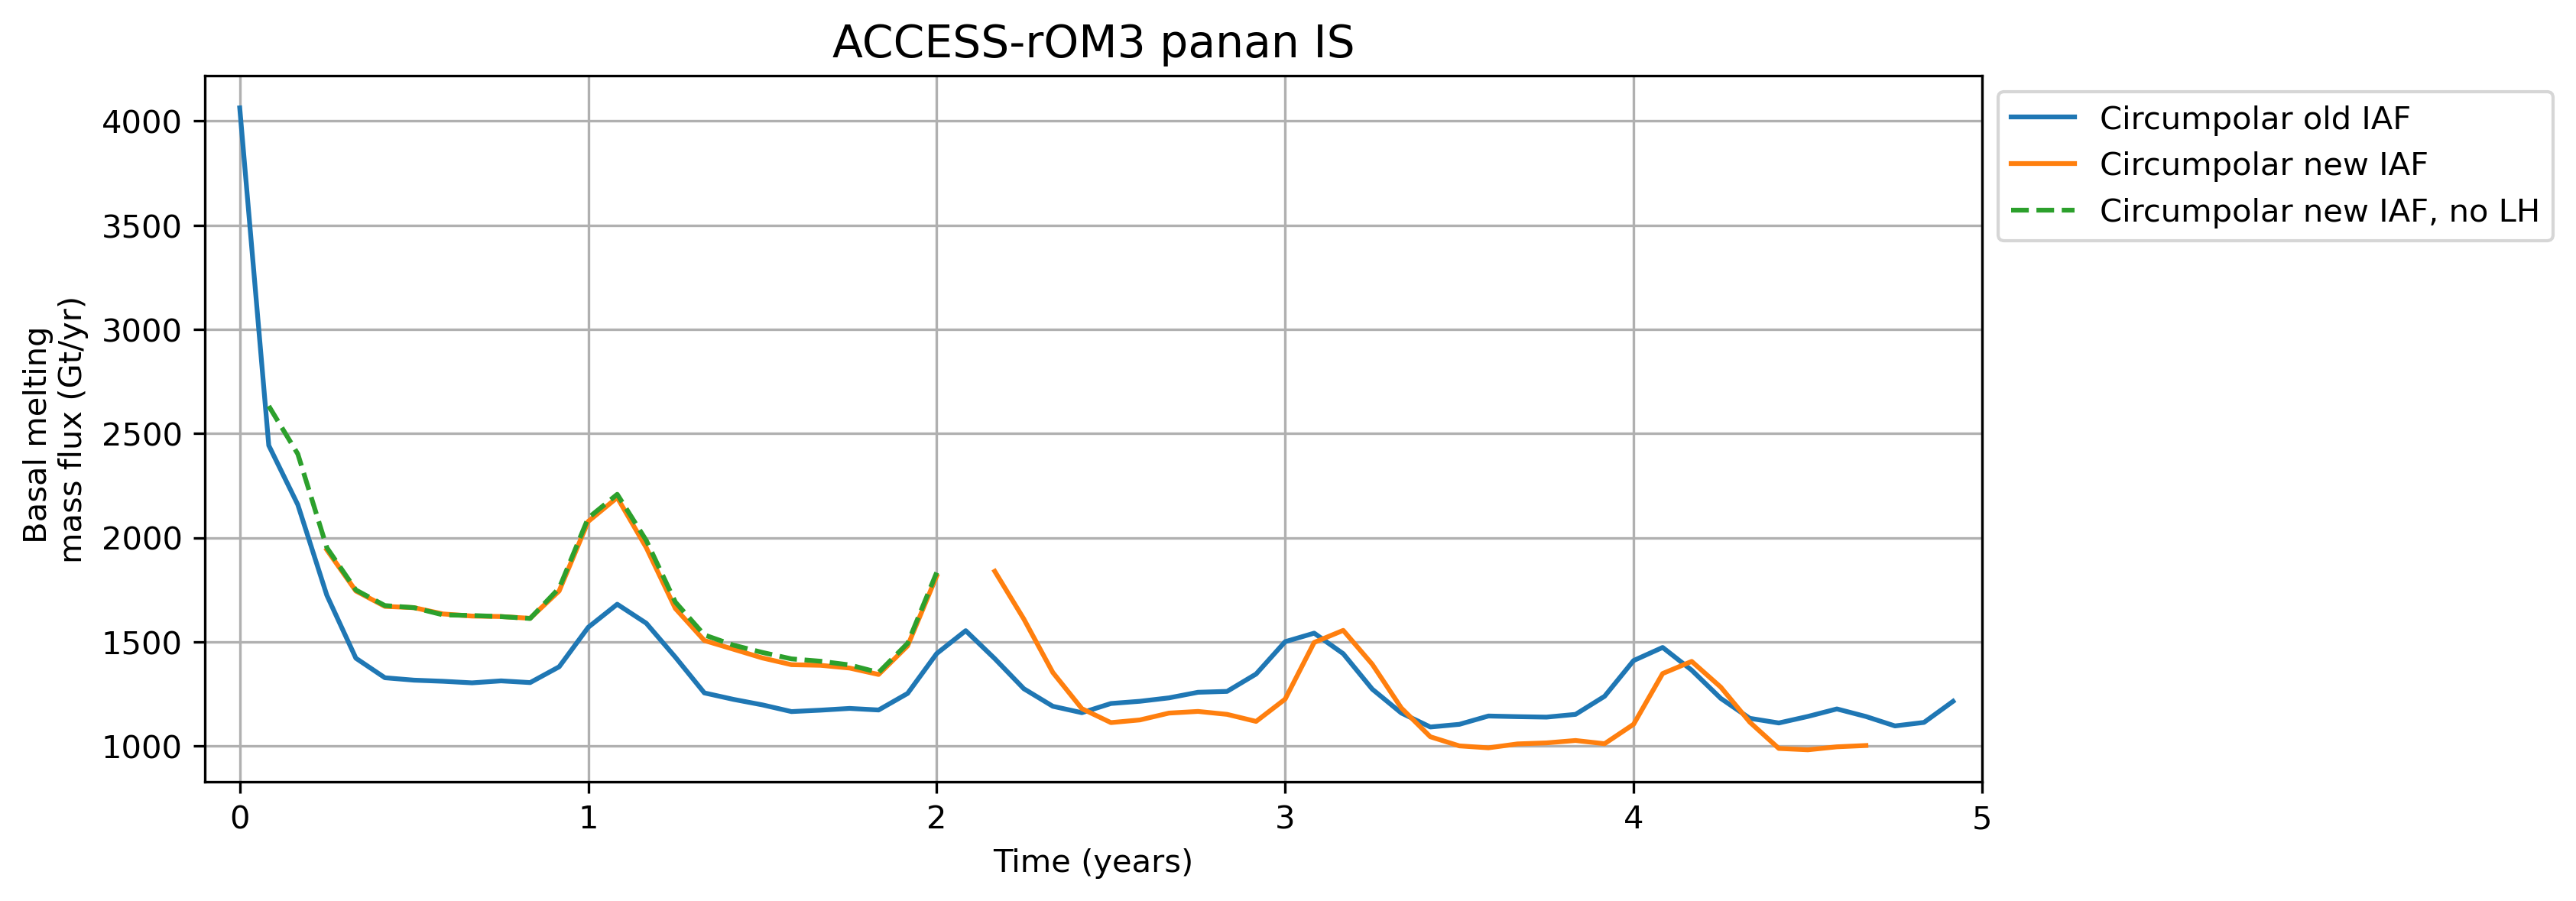

In [7]:
# melt rate for different regions

fig, axes = plt.subplots(figsize = (10,4),dpi = 300, sharex = True)
s_to_yr = 365*24*60*60

# plot new sim
print('Old IAF')
mass_flux1 = (mass_flux_control.mass_flux).isel(time = np.arange(60)).sum(['xT','yT'])/1e12*s_to_yr
axes.plot(np.arange(len(mass_flux1))/12,mass_flux1.values,color = 'C0', ls = '-', label = 'Circumpolar'+ ' old IAF')
print('Circumpolar, end', mass_flux1.values[-1],'Gt/yr')
print('Circumpolar, last 12 months = ',mass_flux1[-12:].mean('time').values,'Gt/yr')
print('New IAF')
mass_flux1 = (mass_flux_new.mass_flux).sum(['xT','yT'])/1e12*s_to_yr
mass_flux1 = np.append(np.append(mass_flux1[:22],np.nan),mass_flux1[22:]) # there is an uncollated month here
axes.plot(np.arange(3,len(mass_flux1)+3)/12,mass_flux1,color = 'C1', ls = '-', label = 'Circumpolar'+ ' new IAF')
print('Circumpolar, end', mass_flux1[-1],'Gt/yr')
print('no LHF')
mass_flux1 = (mass_flux_nlh.mass_flux).sum(['xT','yT'])/1e12*s_to_yr
axes.plot(np.arange(1,len(mass_flux1)+1)/12,mass_flux1.values,color = 'C2', ls = '--', label = 'Circumpolar'+ ' new IAF, no LH')
print('Circumpolar, end', mass_flux1.values[-1],'Gt/yr')
print('Circumpolar, last 12 months = ',mass_flux1[-12:].mean('time').values,'Gt/yr')


plt.legend(loc = 'upper left', ncol = 1, bbox_to_anchor = (1,1))

axes.set_xlabel('Time (years)')
axes.set_ylabel('Basal melting \nmass flux (Gt/yr)')
axes.set_title('ACCESS-rOM3 panan IS', fontsize = 14)
plt.grid()
plt.xlim(-0.1,5)

fig.subplots_adjust(hspace = 0.4)

In [8]:
domains = {'Amundsen sector':
           {'xslice' : slice(-150,-95),
            'yslice' : slice(-78,-72)},
           'Bellingshausen sector':
           {'xslice' : slice(-95,-55),
            'yslice' : slice(-75,-60)},
           'Filchner-Ronne':
           {'xslice' : slice(-90,-30),
            'yslice' : slice(-90,-75)},
            'Dronning Maud Land':
           {'xslice' : slice(-30,55),
            'yslice' : slice(-78,-65)},
            'Amery':
           {'xslice' : slice(55,80),
            'yslice' : slice(-75,-65)},
            'Adelie sector':
           {'xslice' : slice(-280,-190),
            'yslice' : slice(-75,-64)},
            'Ross':
           {'xslice' : slice(-210,-146),
            'yslice' : slice(-90,-75)},
}

IAF old
IAF new


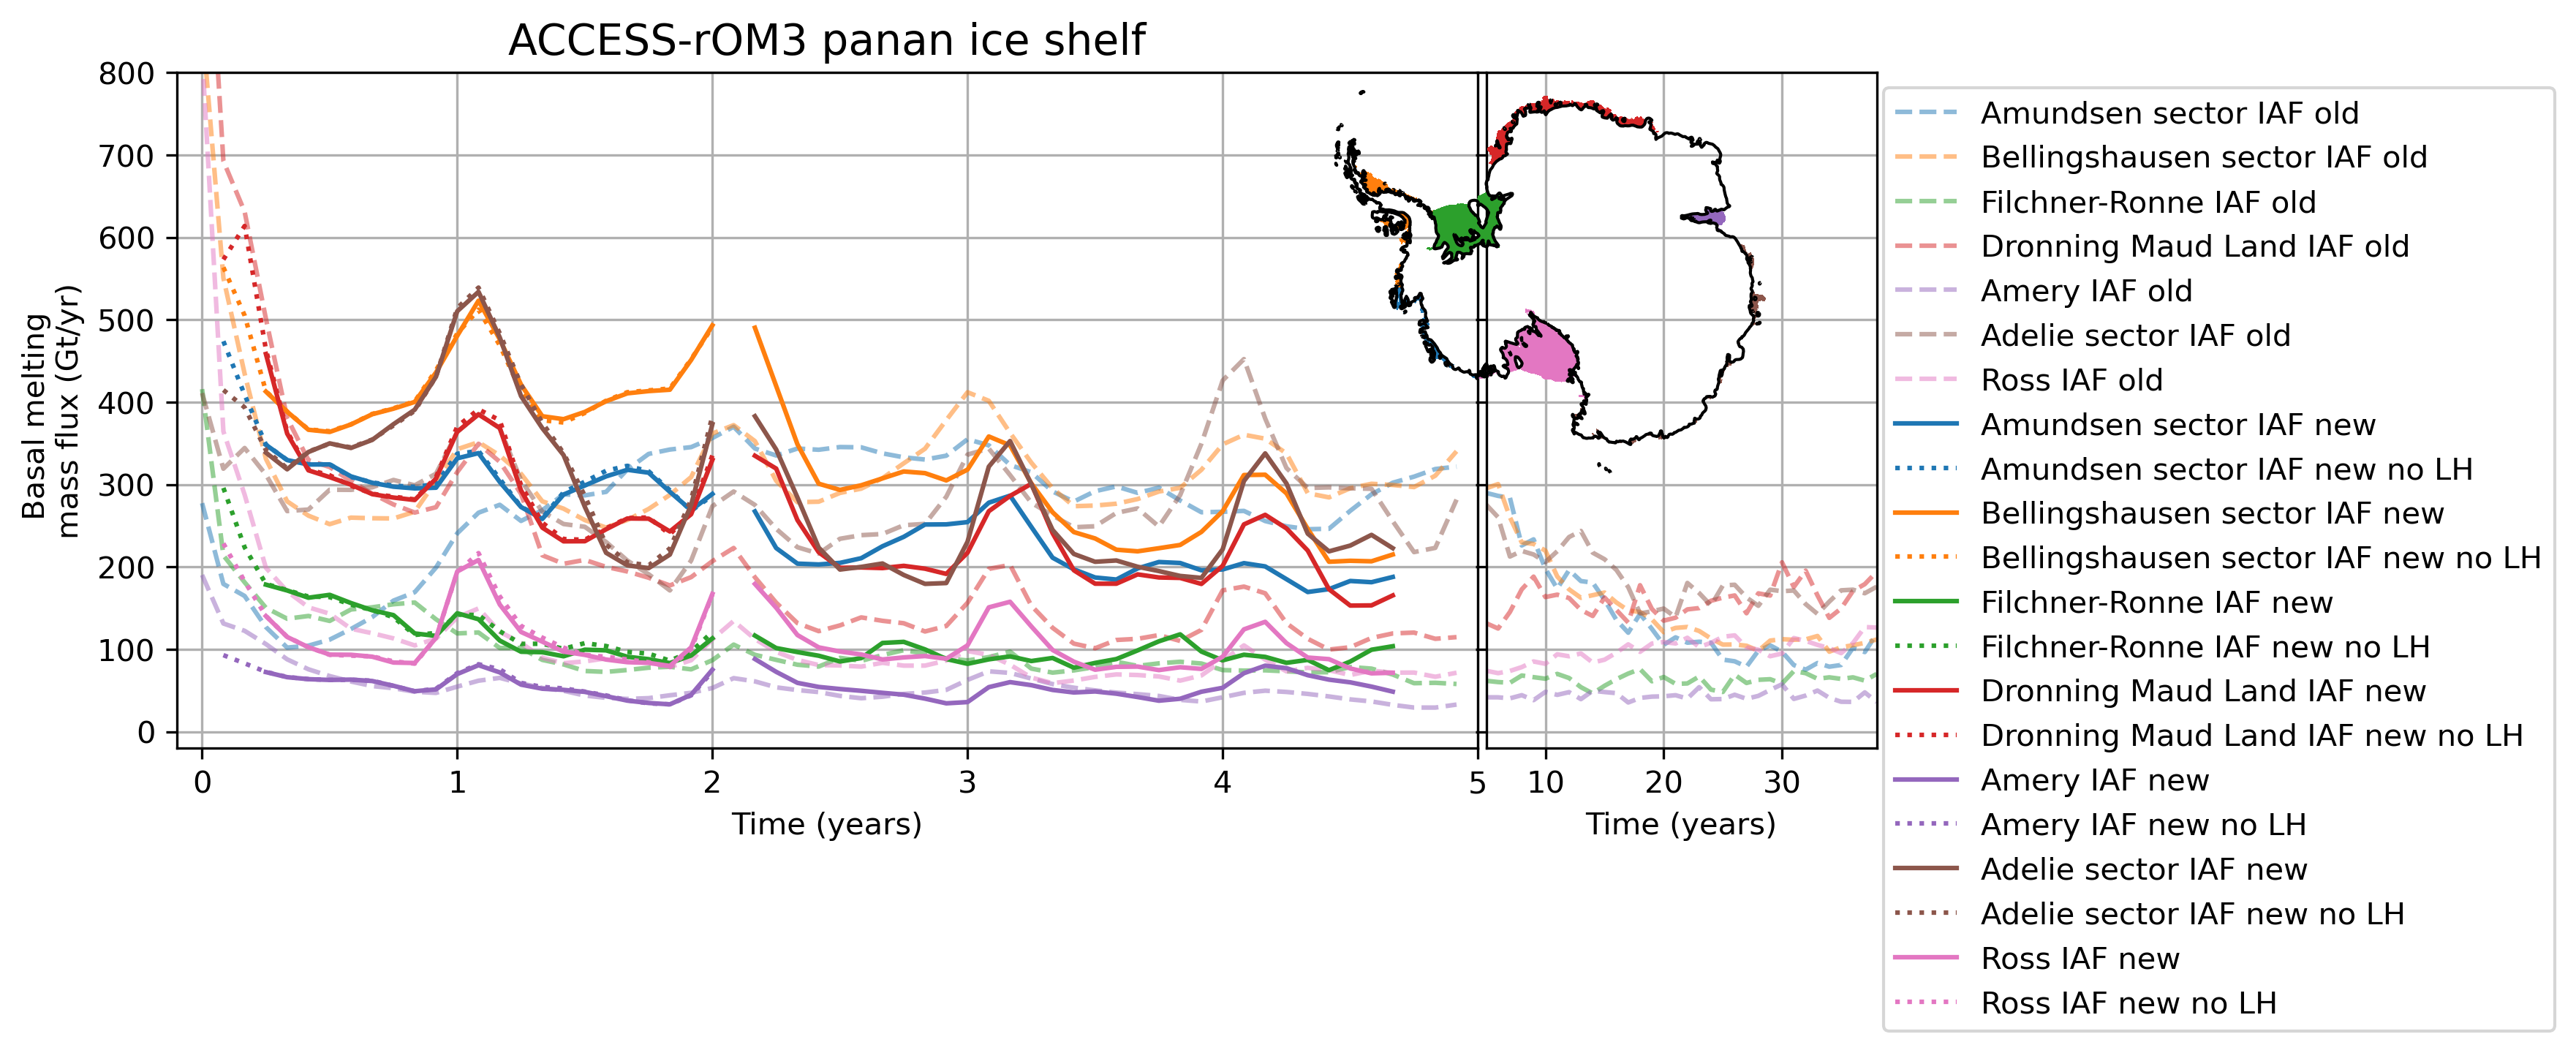

In [9]:
# melt rate for different regions

fig, ax = plt.subplots(ncols = 2,figsize = (10,4),dpi = 300, gridspec_kw = {'width_ratios':[1,0.3]}, sharey = True)
s_to_yr = 365*24*60*60

axes = ax[0]
ax_inset = plt.axes([0.5,0.4,0.5,0.5],projection=ccrs.SouthPolarStereo())
ax_inset.set_extent([-180, 180, -90, -65], ccrs.PlateCarree())
ax_inset.coastlines()
ax_inset.axis('off')

# plot new sim
print('IAF old')
for i in np.arange(7):
    domain = ['Amundsen sector','Bellingshausen sector',
              'Filchner-Ronne','Dronning Maud Land',
              'Amery','Adelie sector','Ross'][i]
    colors = ['C0','C1','C2','C3','C4','C5','C6','C7'][i]
    mass_flux1 = (mass_flux_control).mass_flux.isel(time = np.arange(60)).sel(xT = domains[domain]['xslice'],
                     yT = domains[domain]['yslice']).sum(['xT','yT'])/1e12*s_to_yr
    axes.plot(np.arange(len(mass_flux1))/12,mass_flux1.values,label = domain + ' IAF old',color = colors, ls ='--', alpha = 0.5)
    mass_flux1 = (mass_flux_control).mass_flux.isel(time = np.arange(60,12*39)).sel(xT = domains[domain]['xslice'],
                     yT = domains[domain]['yslice']).sum(['xT','yT'])/1e12*s_to_yr
    mass_flux1 = mass_flux1.groupby('time.year').mean('time')
    ax[1].plot(np.arange(5,len(mass_flux1)+5),mass_flux1.values,color = colors, ls ='--', alpha = 0.5)
    mass_flux_mask = (mass_flux_control).mass_flux.sel(xT = domains[domain]['xslice'],
                     yT = domains[domain]['yslice']).isel(time = 0)
    mass_flux_mask = mass_flux_mask.where(mass_flux_mask!=0)
    mass_flux_mask = mass_flux_mask*0+1
    ax_inset.contourf(mass_flux_mask.xT,mass_flux_mask.yT,mass_flux_mask,
                        levels = [0.5,1.5], colors = colors, transform=ccrs.PlateCarree())

print('IAF new')
for i in np.arange(7):
    domain = ['Amundsen sector','Bellingshausen sector',
              'Filchner-Ronne','Dronning Maud Land',
              'Amery','Adelie sector','Ross'][i]
    colors = ['C0','C1','C2','C3','C4','C5','C6','C7'][i]
    mass_flux1 = (mass_flux_new).mass_flux.sel(xT = domains[domain]['xslice'],
                     yT = domains[domain]['yslice']).sum(['xT','yT'])/1e12*s_to_yr
    mass_flux1 = np.append(np.append(mass_flux1[:22],np.nan),mass_flux1[22:]) # there is an uncollated month here
    axes.plot(np.arange(3,len(mass_flux1)+3)/12,mass_flux1,label = domain + ' IAF new',color = colors, ls ='-')
    mass_flux1 = (mass_flux_nlh).mass_flux.sel(xT = domains[domain]['xslice'],
                     yT = domains[domain]['yslice']).sum(['xT','yT'])/1e12*s_to_yr
    axes.plot(np.arange(1,len(mass_flux1)+1)/12,mass_flux1.values,label = domain + ' IAF new no LH',color = colors, ls ='dotted')

axes.legend(loc = 'upper left', ncol = 1, bbox_to_anchor = (1.3,1))

axes.set_xlabel('Time (years)')
axes.set_ylabel('Basal melting \nmass flux (Gt/yr)')
axes.set_title('ACCESS-rOM3 panan ice shelf', fontsize = 14)
axes.grid()
ax[1].grid()
axes.set_xlim(-0.1,5)
ax[1].set_xlim(5,38)
ax[1].set_ylim(-20,800)
ax[0].set_ylim(-20,800)
ax[1].set_ylabel('')
ax[1].set_xlabel('Time (years)')


fig.subplots_adjust(wspace = 0.01)

# Assorted maps

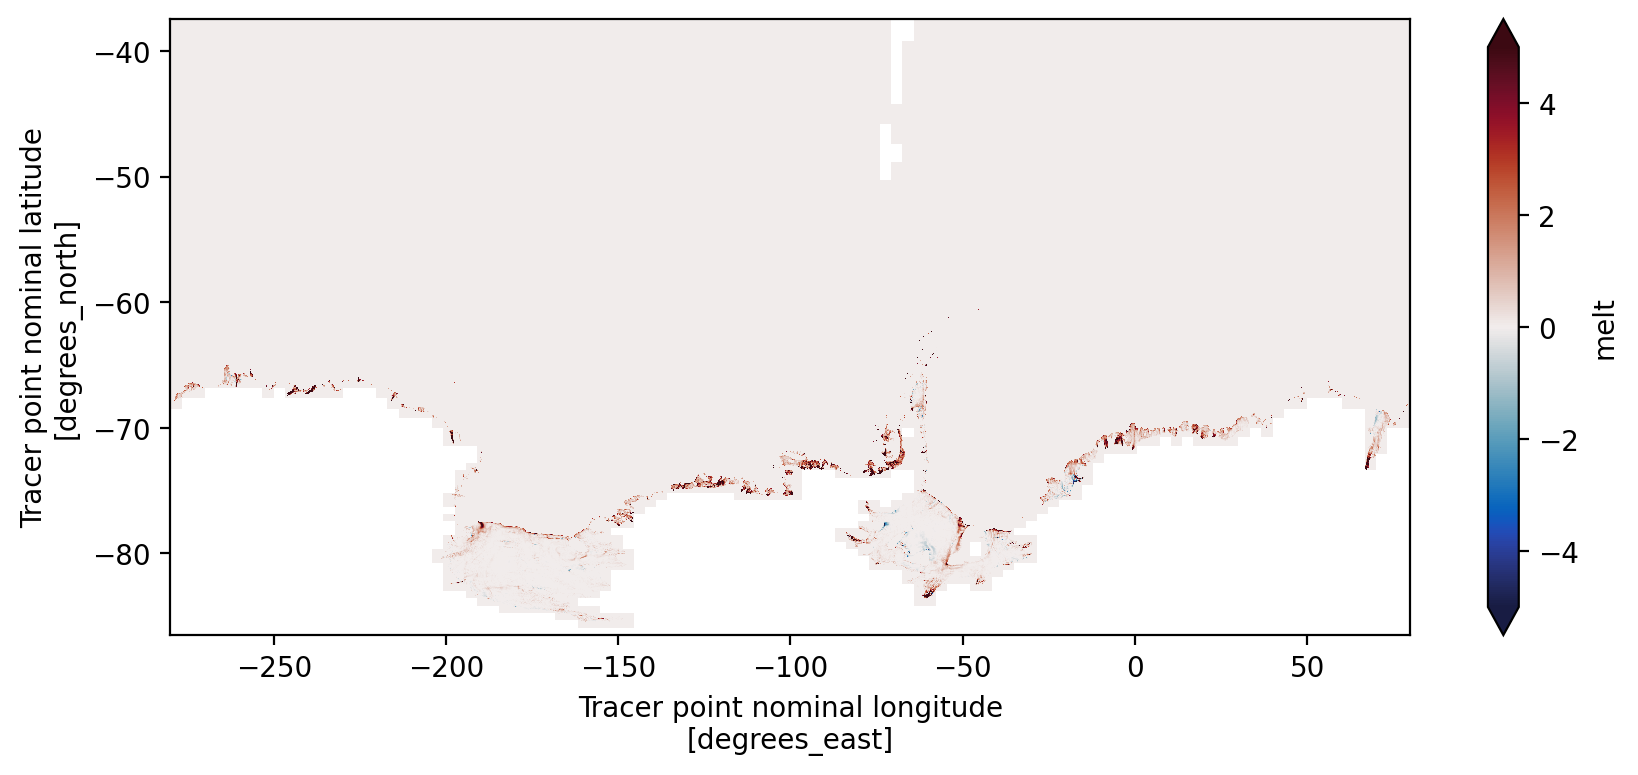

In [10]:
fig,ax = plt.subplots(figsize = (10,4),dpi = 200)
melt_new.melt.isel(time = np.arange(36,48)).mean('time').plot(vmax = 5, vmin = -5, cmap = cmo.cm.balance)

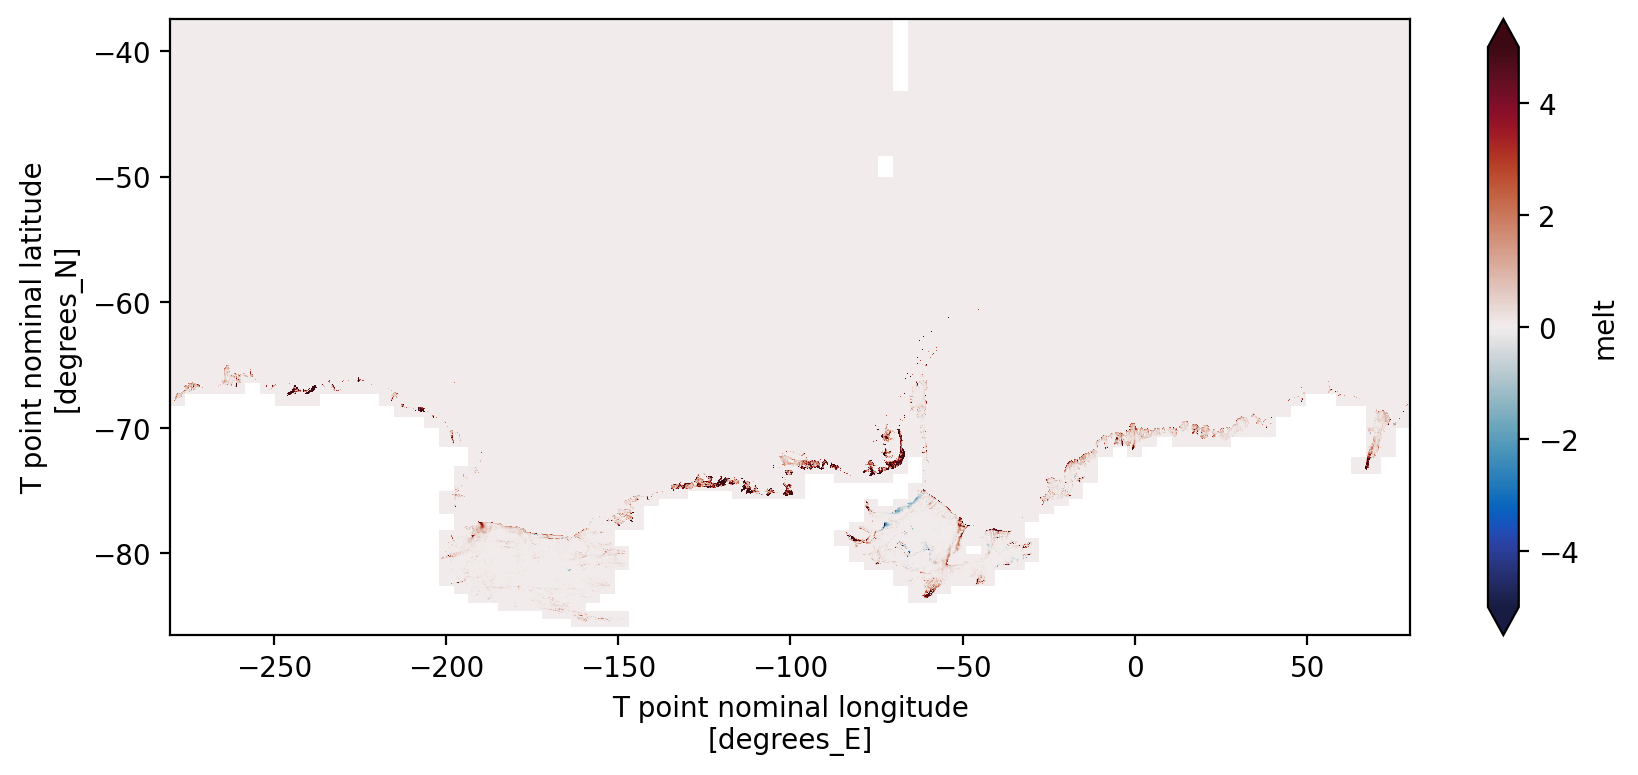

In [11]:
fig,ax = plt.subplots(figsize = (10,4),dpi = 200)
melt_control.melt.isel(time = np.arange(36,48)).mean('time').plot(vmax = 5, vmin = -5, cmap = cmo.cm.balance)

Text(0.5, 1.0, 'Year 4: New - control tob')

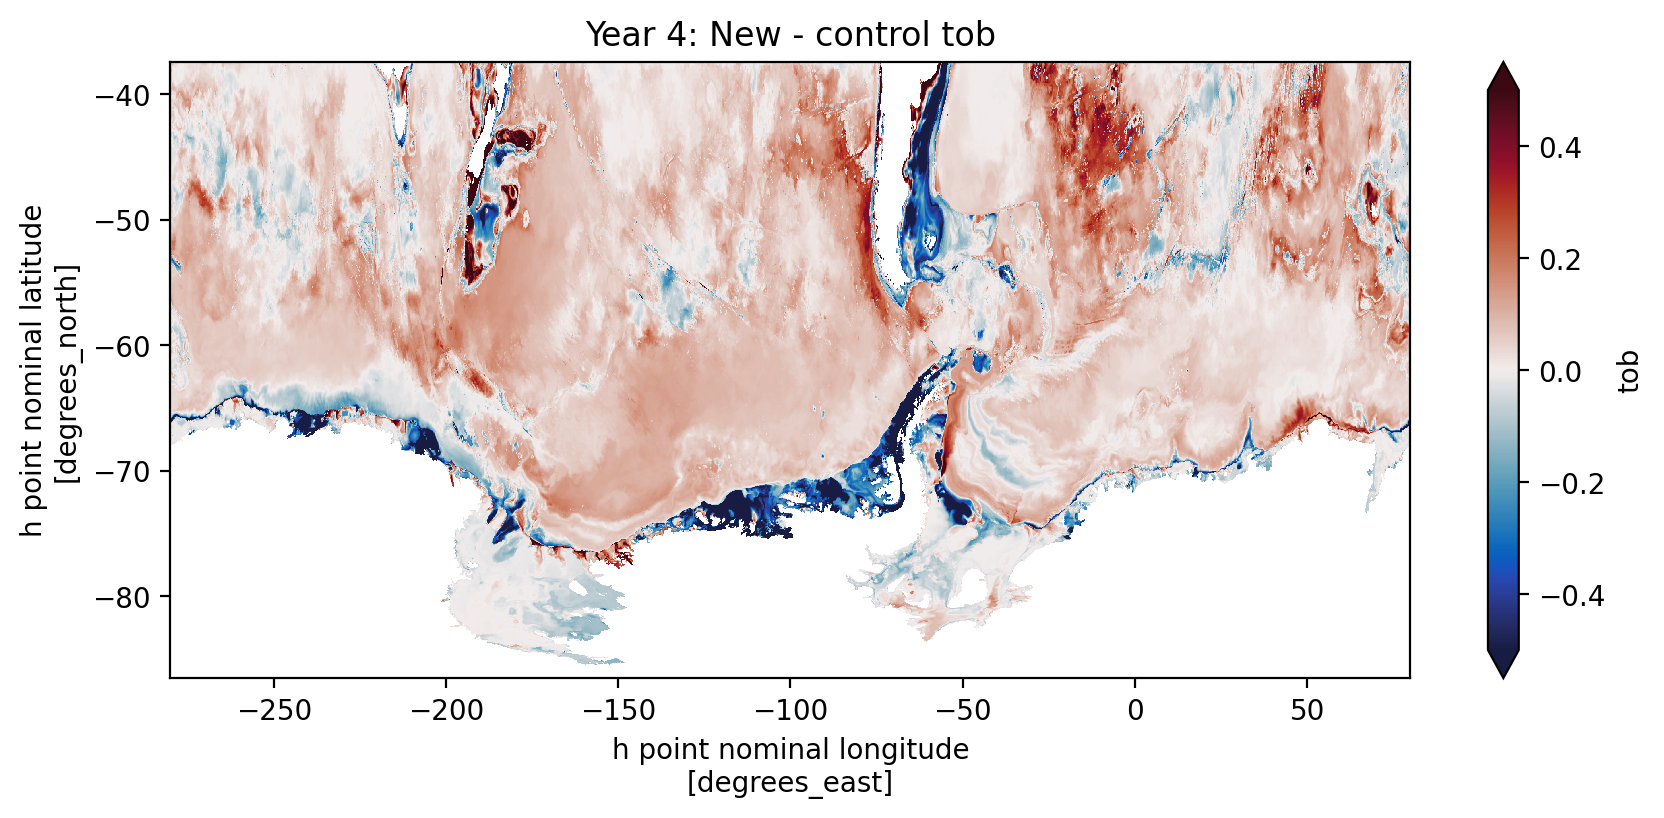

In [12]:
fig,ax = plt.subplots(figsize = (10,4),dpi = 200)
(tob_new.tob.isel(time = np.arange(36-3,48-3)).mean('time')-\
  tob_control.tob.isel(time = np.arange(36,48)).mean('time')).plot(vmax = 0.5, vmin = -0.5, cmap = cmo.cm.balance)
plt.title('Year 4: New - control tob')

Text(0.5, 1.0, 'April Year 1 to March Year 2 - New - control tob')

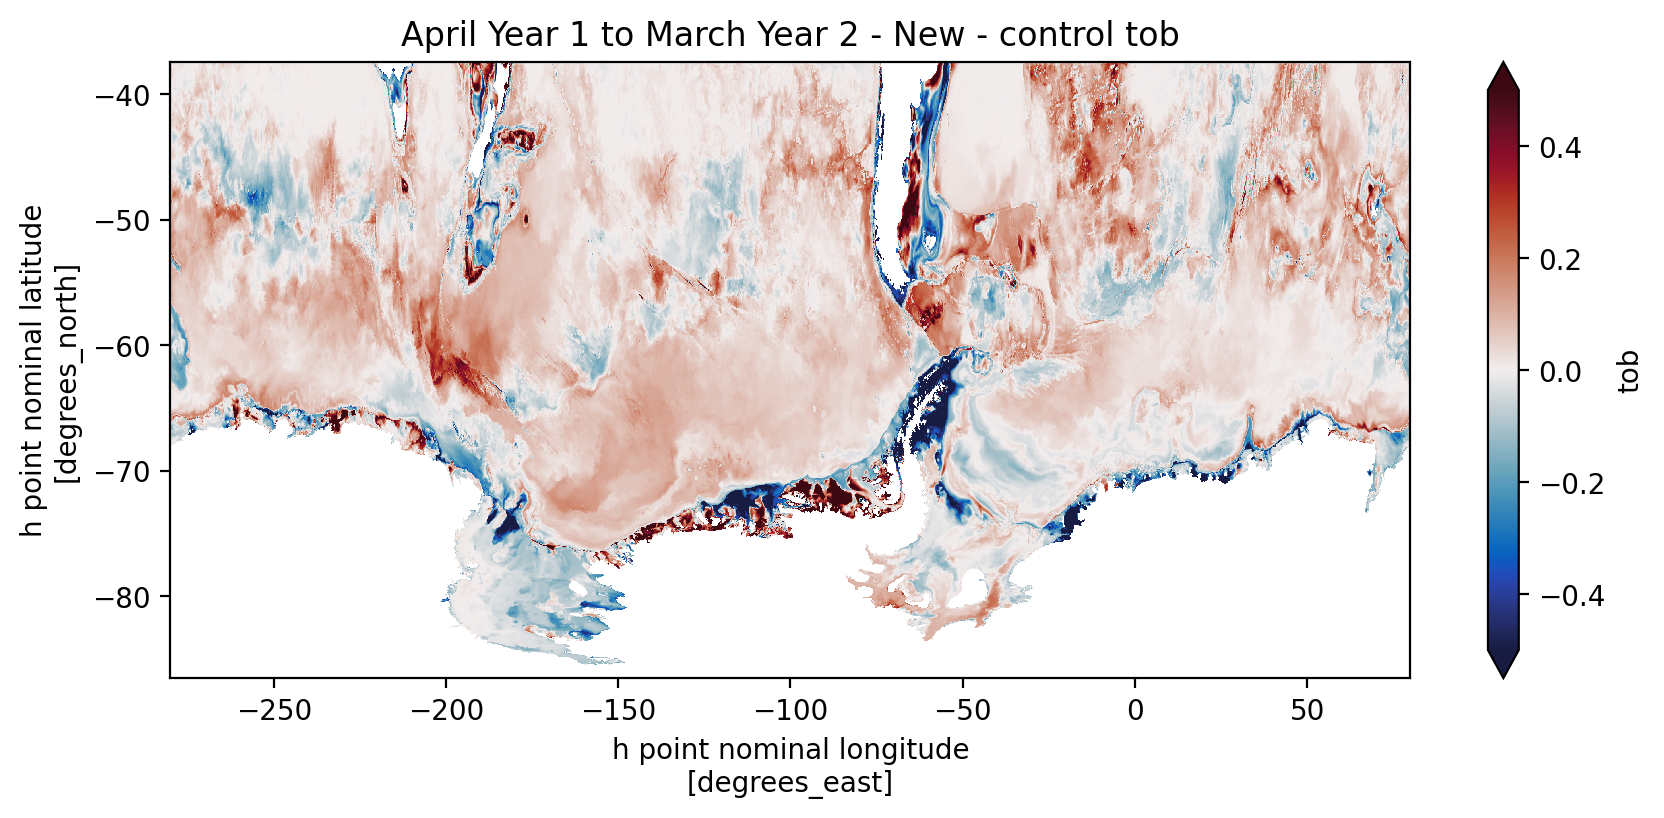

In [13]:
fig,ax = plt.subplots(figsize = (10,4),dpi = 200)
(tob_new.tob.isel(time = np.arange(12)).mean('time')-\
  tob_control.tob.isel(time = np.arange(3,15)).mean('time')).plot(vmax = 0.5, vmin = -0.5, cmap = cmo.cm.balance)
plt.title('April Year 1 to March Year 2 - New - control tob')

Text(0.5, 1.0, 'Year 4: New - control sob')

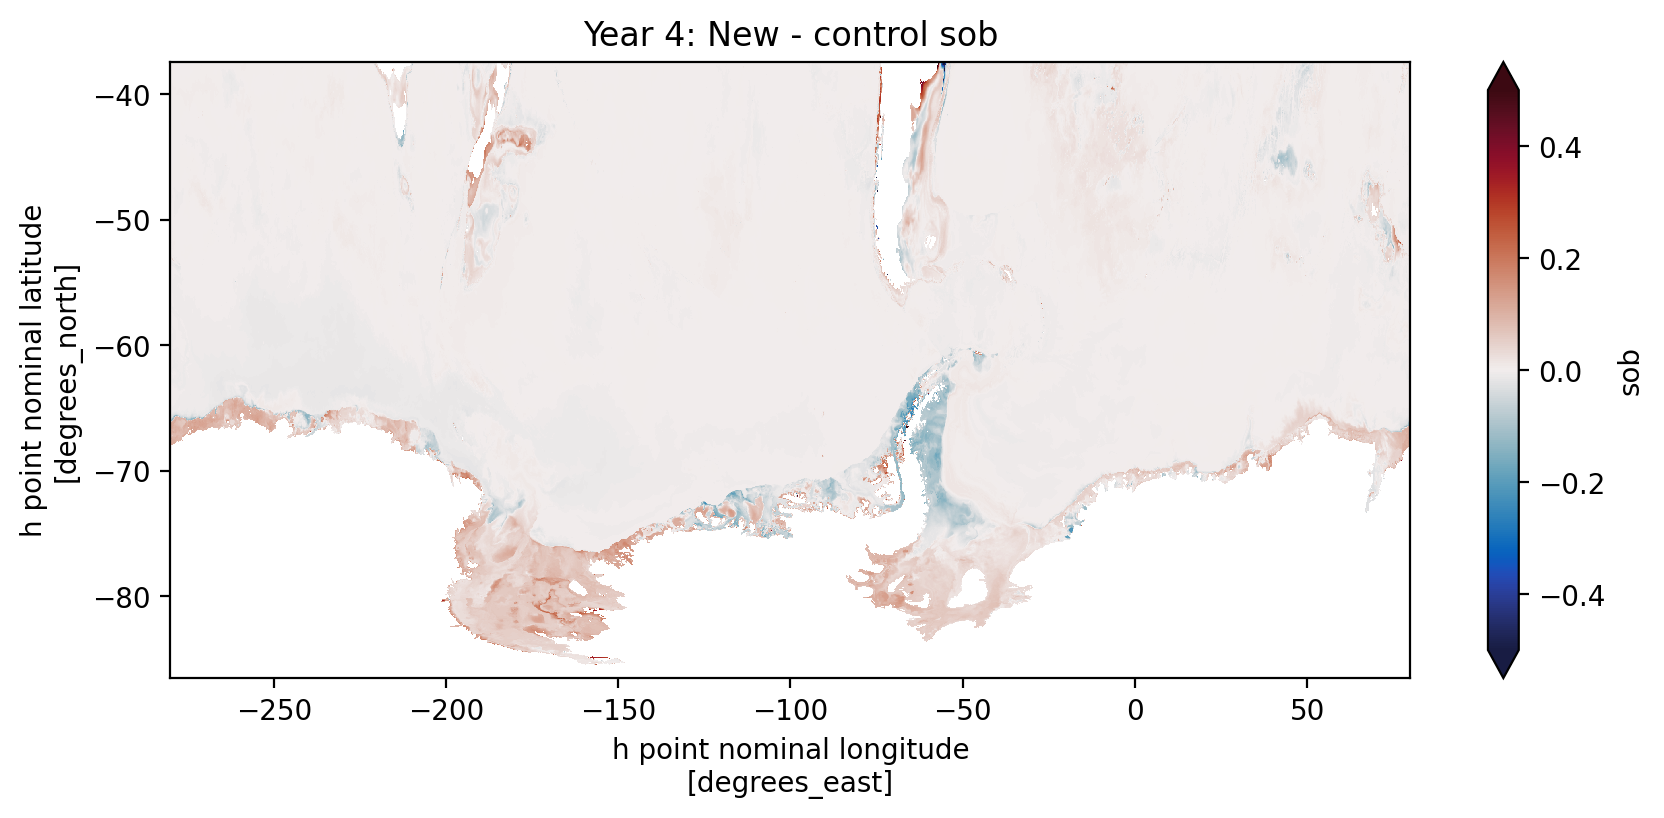

In [14]:
fig,ax = plt.subplots(figsize = (10,4),dpi = 200)
(sob_new.sob.isel(time = np.arange(36-3,48-3)).mean('time')-\
  sob_control.sob.isel(time = np.arange(36,48)).mean('time')).plot(vmax = 0.5, vmin = -0.5, cmap = cmo.cm.balance)
plt.title('Year 4: New - control sob')

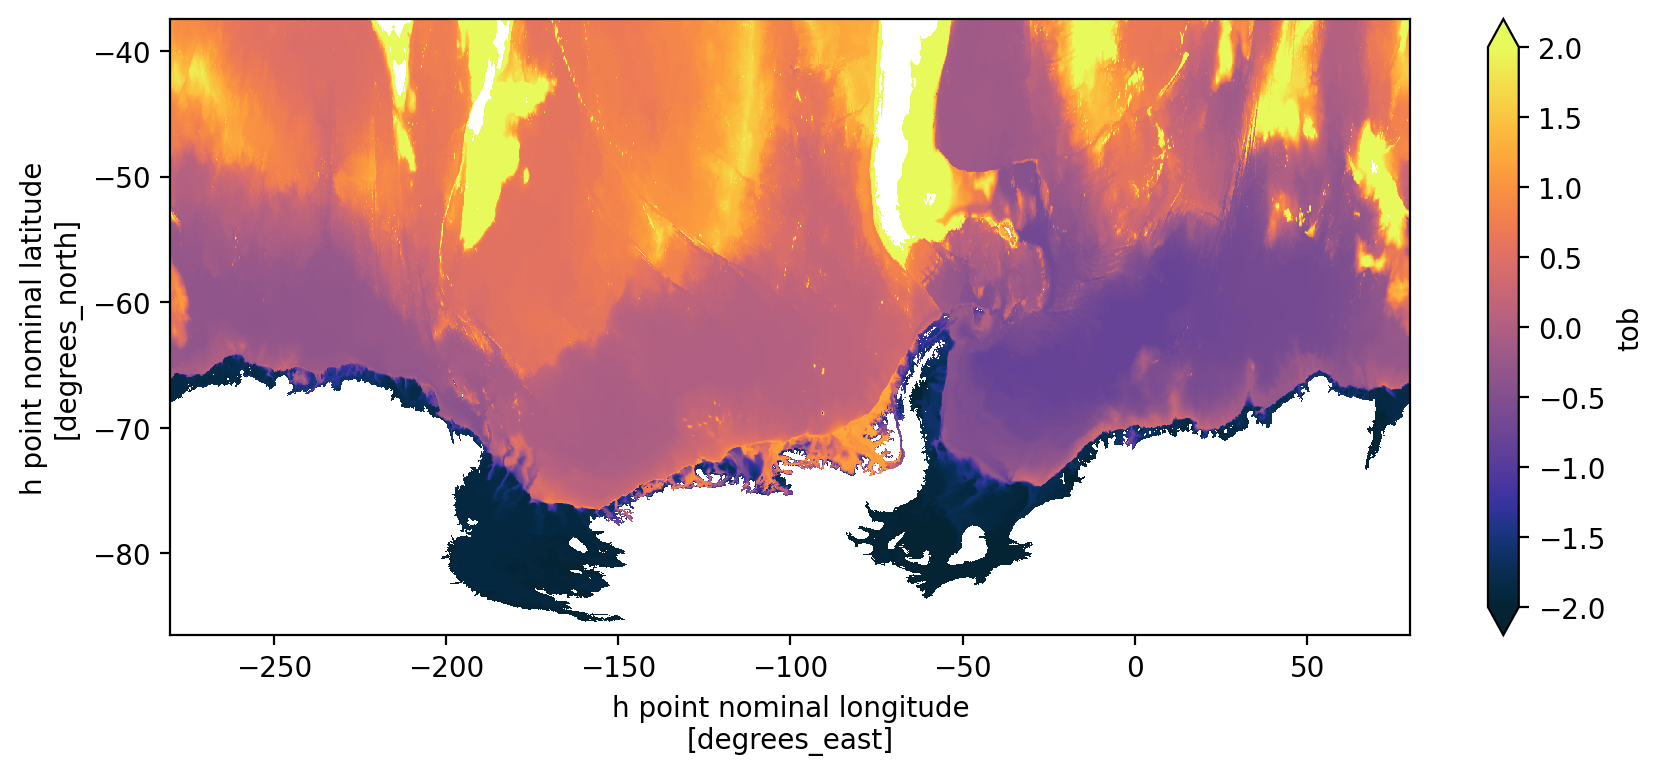

In [15]:
fig,ax = plt.subplots(figsize = (10,4),dpi = 200)
tob_new.tob.isel(time = np.arange(24-3,36-3)).mean('time').plot(vmax = 2, vmin = -2, cmap = cmo.cm.thermal)

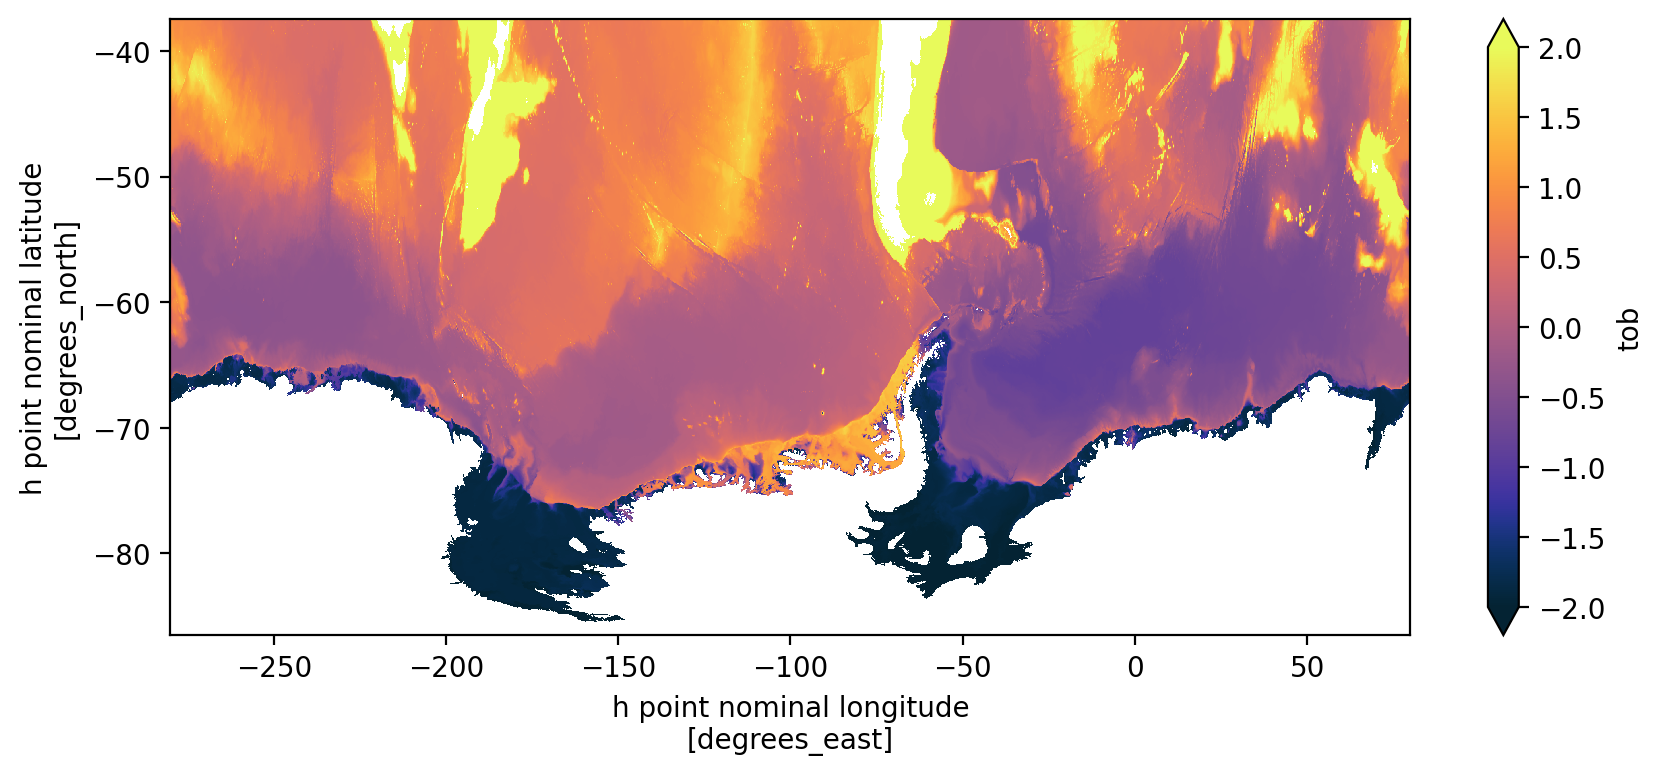

In [16]:
fig,ax = plt.subplots(figsize = (10,4),dpi = 200)
tob_control.tob.isel(time = np.arange(24,36)).mean('time').plot(vmax = 2, vmin = -2, cmap = cmo.cm.thermal)

(-87.0, -59.0)

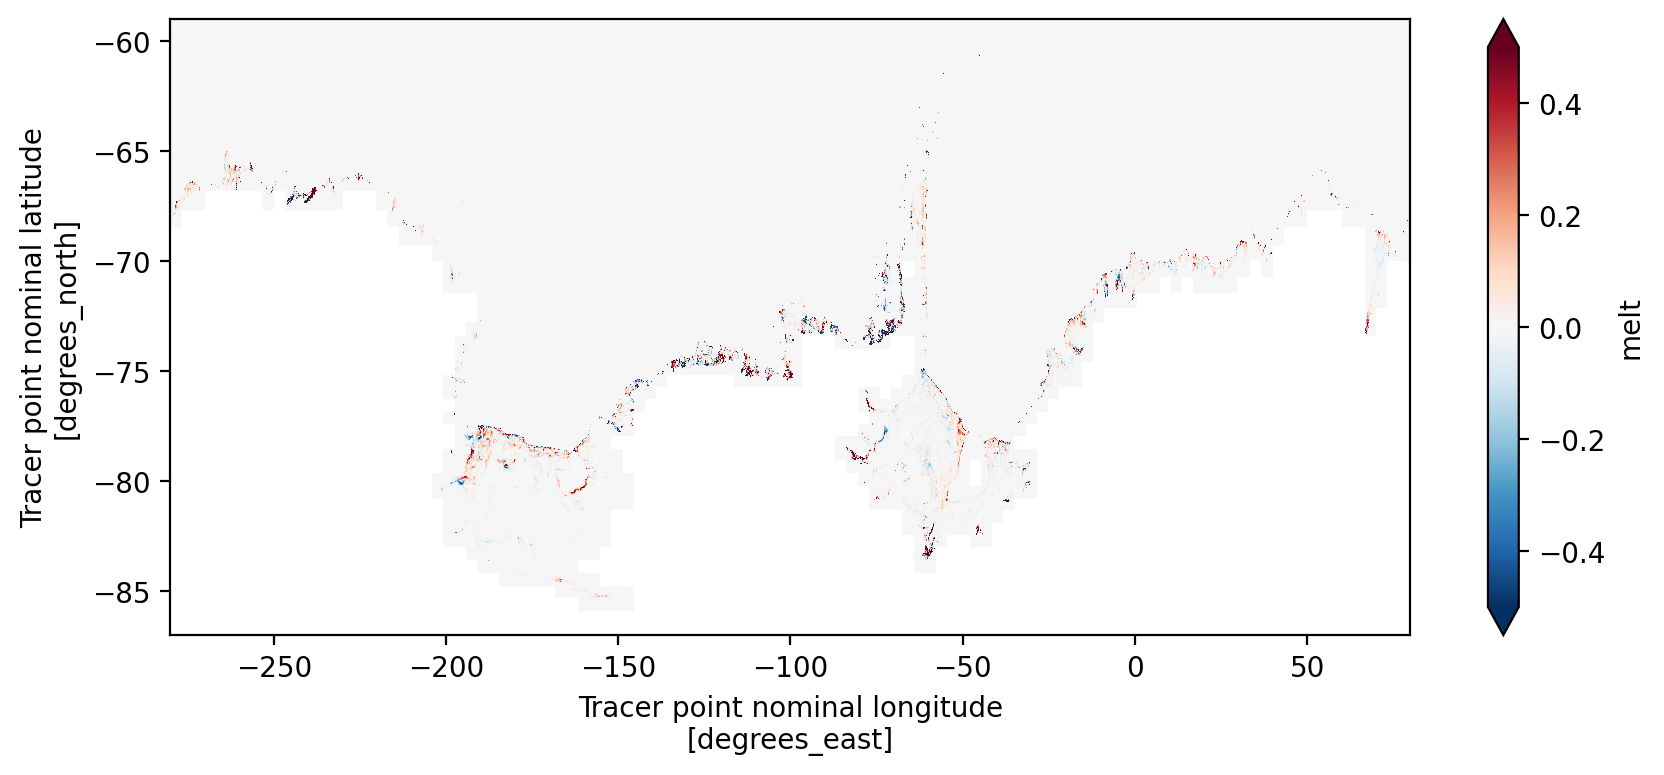

In [17]:
fig,ax = plt.subplots(figsize = (10,4),dpi = 200)
(melt_nlh.melt.sel(time = slice('1976-01-01','1976-12-31')).mean('time') - melt_new.melt.sel(time = slice('1976-01-01','1976-12-31')).mean('time')).plot(vmax = 0.5, vmin = -0.5, cmap = 'RdBu_r')
plt.ylim(-87,-59)

(-120.0, -90.0)

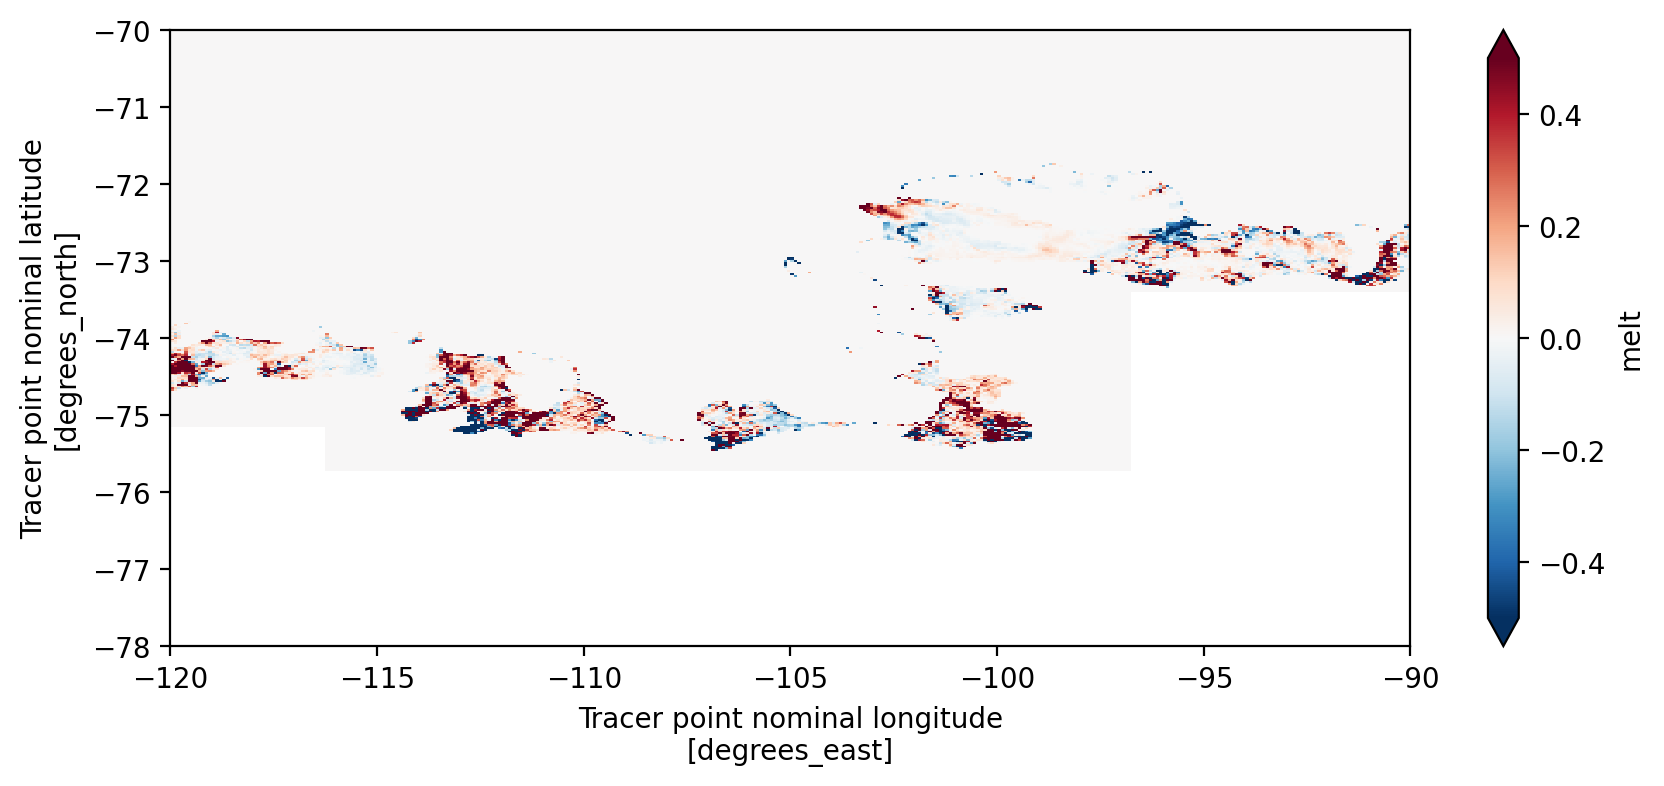

In [18]:
fig,ax = plt.subplots(figsize = (10,4),dpi = 200)
(melt_nlh.melt.sel(time = slice('1976-01-01','1976-12-31')).mean('time') - melt_new.melt.sel(time = slice('1976-01-01','1976-12-31')).mean('time')).plot(vmax = 0.5, vmin = -0.5, cmap = 'RdBu_r')
plt.ylim(-78,-70)
plt.xlim(-120,-90)

(300.0, 1000.0)

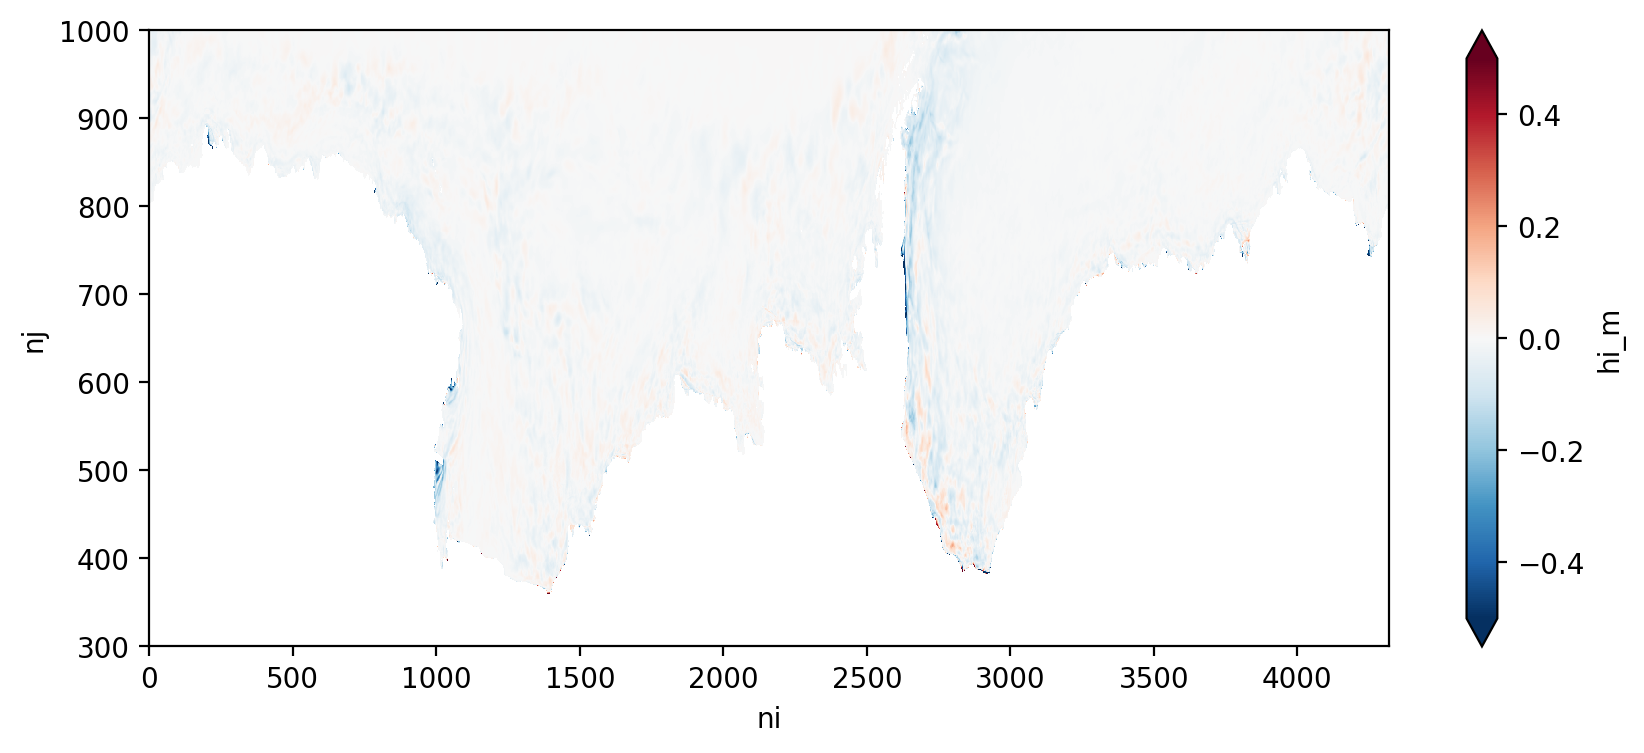

In [19]:
fig,ax = plt.subplots(figsize = (10,4),dpi = 200)
(hi_m_nlh.hi_m.sel(time = slice('1976-01-01','1976-12-31')).mean('time') - hi_m_new.hi_m.sel(time = slice('1976-01-01','1976-12-31')).mean('time')).plot(vmax = 0.5, vmin = -0.5, cmap = 'RdBu_r')
plt.ylim(300,1000)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 49.26 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 47.73 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/distributed/cli

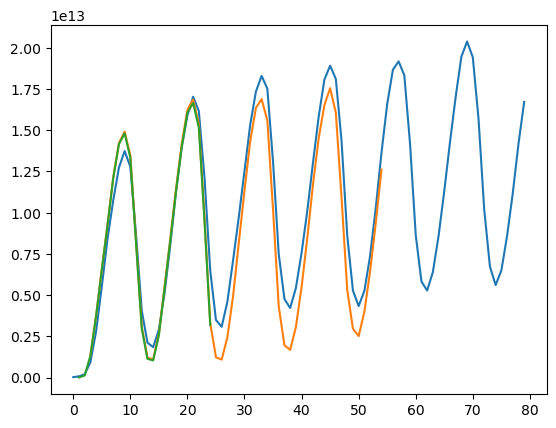

In [15]:
# sea ice volume

siv_control = (hi_m_control.hi_m.isel(time = np.arange(80))*area.areacello.values).sum(['ni','nj'])
plt.plot(np.arange(len(siv_control)),siv_control.values)

siv_new = (hi_m_new.hi_m*area.areacello.values).sum(['ni','nj'])
plt.plot(np.arange(3,len(siv_new)+3),siv_new.values)

siv_nlh = (hi_m_nlh.hi_m*area.areacello.values).sum(['ni','nj'])
plt.plot(np.arange(1,len(siv_nlh)+1),siv_nlh.values)

# Volume averagedd density across the Amundsen shelf


/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 11.78 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
 

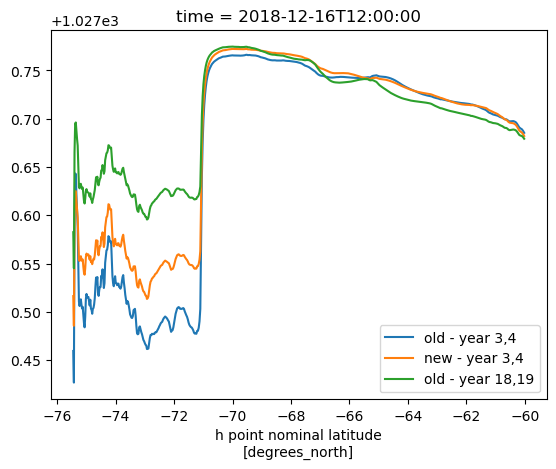

In [20]:
xslice = slice(-107,-104)
yslice = slice(-80,-60)
volume = volcello.sel(xh = xslice, yh = yslice)
((rhopot0_control.rhopot0.isel(time = np.arange(24+3,48+3)).sel(xh = xslice, yh = yslice).mean('time')*volume).sum('xh').sum('z_l')/(volume.sum('xh').sum('z_l'))).plot(label = 'old - year 3,4')
((rhopot0_new.rhopot0.isel(time = np.arange(24,48)).sel(xh = xslice, yh = yslice).mean('time')*volume).sum('xh').sum('z_l')/(volume.sum('xh').sum('z_l'))).plot(label = 'new - year 3,4')
((rhopot0_control.rhopot0.isel(time = np.arange(15*12+24+3,15*12+48+3)).sel(xh = xslice, yh = yslice).mean('time')*volume).sum('xh').sum('z_l')/(volume.sum('xh').sum('z_l'))).plot(label = 'old - year 18,19')

plt.legend()

So shelf is denser than original run at same time. But still lighter than towards end of old run where Amundsen/Bellingshausen was barely melting.